In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_csv("../data/train.csv")

label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df["target"] = (
    df[label_cols]
    .sum(axis=1)
    .gt(0)
    .astype(int)
)

In [3]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["comment_text"],
    df["target"],
    test_size=0.2,
    random_state=42,
    stratify=df["target"]
)

In [4]:
tfidf = TfidfVectorizer(
    max_features=10000
)

X_train = tfidf.fit_transform(train_texts)
X_val = tfidf.transform(val_texts)

In [5]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train,
    train_labels
)

baseline_preds = baseline_model.predict(
    X_val
)

print(classification_report(
    val_labels,
    baseline_preds
))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28670
           1       0.92      0.63      0.74      3245

    accuracy                           0.96     31915
   macro avg       0.94      0.81      0.86     31915
weighted avg       0.95      0.96      0.95     31915



In [6]:
baseline_precision = precision_score(
    val_labels,
    baseline_preds
)

baseline_recall = recall_score(
    val_labels,
    baseline_preds
)

baseline_f1 = f1_score(
    val_labels,
    baseline_preds
)

In [7]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(
    X_train,
    train_labels
)

balanced_preds = balanced_model.predict(
    X_val
)

print(classification_report(
    val_labels,
    balanced_preds
))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96     28670
           1       0.62      0.88      0.73      3245

    accuracy                           0.93     31915
   macro avg       0.80      0.91      0.84     31915
weighted avg       0.95      0.93      0.94     31915



In [8]:
balanced_precision = precision_score(
    val_labels,
    balanced_preds
)

balanced_recall = recall_score(
    val_labels,
    balanced_preds
)

balanced_f1 = f1_score(
    val_labels,
    balanced_preds
)

In [9]:
rus = RandomUnderSampler(
    random_state=42
)

X_train_under, y_train_under = rus.fit_resample(
    X_train,
    train_labels
)

In [10]:
pd.Series(y_train_under).value_counts()

target
0    12980
1    12980
Name: count, dtype: int64

In [11]:
under_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

under_model.fit(
    X_train_under,
    y_train_under
)

under_preds = under_model.predict(
    X_val
)

print(classification_report(
    val_labels,
    under_preds
))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95     28670
           1       0.55      0.88      0.68      3245

    accuracy                           0.91     31915
   macro avg       0.77      0.90      0.81     31915
weighted avg       0.94      0.91      0.92     31915



In [12]:
under_precision = precision_score(
    val_labels,
    under_preds
)

under_recall = recall_score(
    val_labels,
    under_preds
)

under_f1 = f1_score(
    val_labels,
    under_preds
)

In [13]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Class Weight Balanced",
        "Random Undersampling"
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        under_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        under_recall
    ],
    "F1 Score": [
        baseline_f1,
        balanced_f1,
        under_f1
    ]
})

results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.916704,0.627427,0.744969
1,Class Weight Balanced,0.620449,0.877042,0.726762
2,Random Undersampling,0.550327,0.882897,0.678026


Although the class-weighted model achieved substantially higher recall (87.7%), the standard Logistic Regression model achieved the highest overall F1-score (74.5%) and was therefore selected as the strongest traditional baseline. The class-weighted model was retained as an alternative when prioritizing toxic content detection over precision.

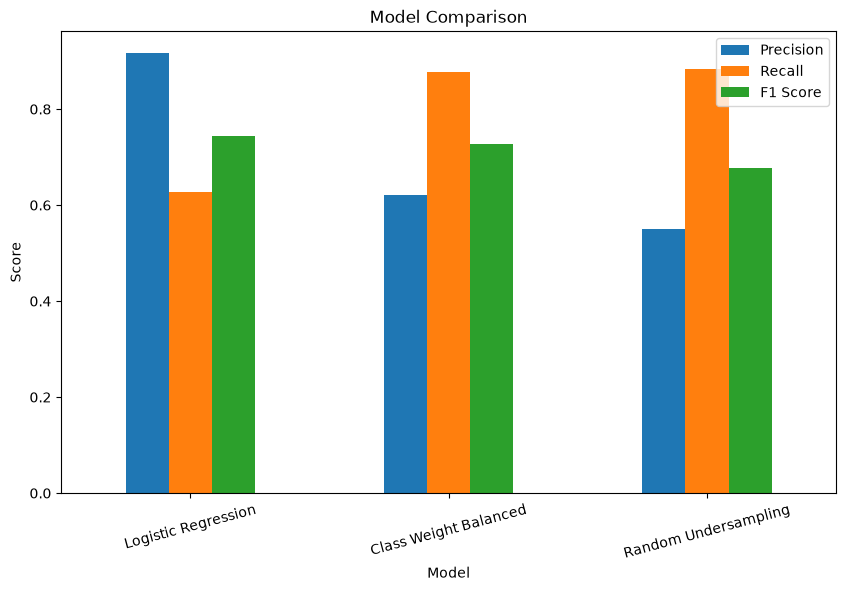

In [14]:
results.set_index("Model")[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.xticks(rotation=15)

plt.show()

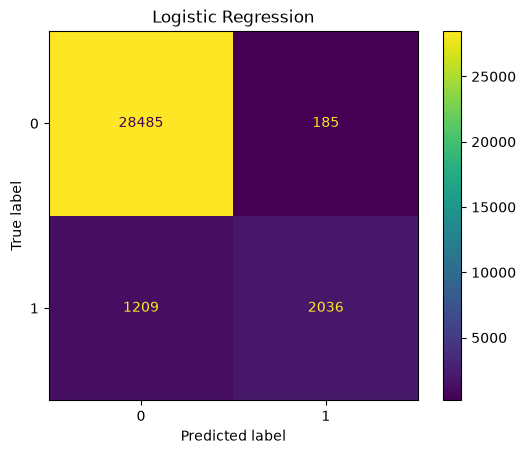

In [16]:
cm = confusion_matrix(
    val_labels,
    baseline_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression")

plt.show()

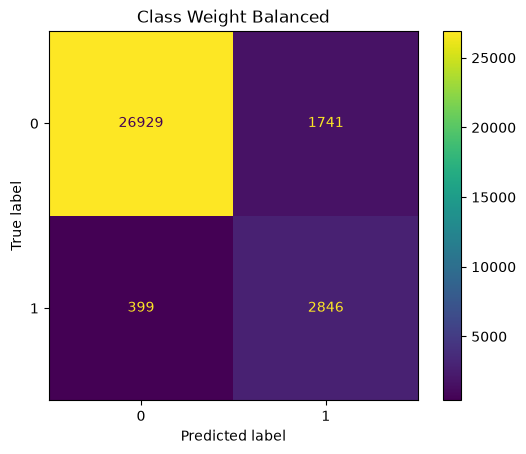

In [17]:
cm = confusion_matrix(
    val_labels,
    balanced_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Class Weight Balanced")

plt.show()

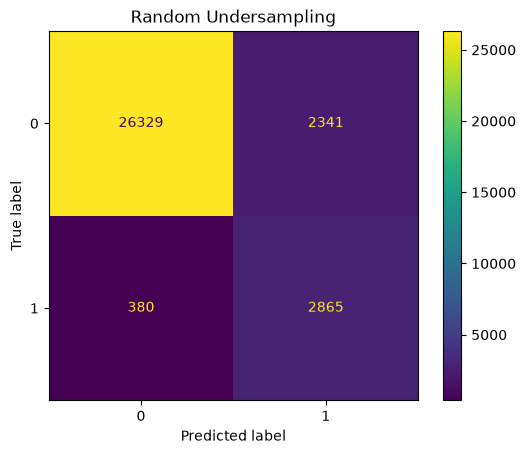

In [18]:
cm = confusion_matrix(
    val_labels,
    under_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Undersampling")

plt.show()

The standard Logistic Regression model produced the fewest false positives, resulting in high precision (91.7%). However, it missed a considerable number of toxic comments, leading to lower recall (62.7%). In contrast, the class-weighted and undersampled models reduced false negatives significantly, improving recall at the expense of precision.